# Kapitel 3 – Regression

Individuella övningsuppgifter.

> Arbeta fråga för fråga. Använd kurslitteraturen som primär referens och formulera svaren med egna ord.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Fråga 1

**Frågeställning:**

### Vad kännetecknar regressionsproblem? Ge några exempel på tillämpningsområden.

**Svar:**

Regression används när målet är att förutsäga ett numeriskt värde.

Exempel på tillämpningsområden är:

- förutsäga huspriser
- uppskatta lön
- prognostisera försäljning
- förutsäga temperatur

Gemensamt är att outputen är ett kontinuerligt numeriskt värde istället för en klass eller kategori.

## Fråga 2

**Frågeställning:**

### Förklara utvärderingsmåtten RMSE, MSE och MAE.

**Svar:**

**MSE (Mean Squared Error)** mäter genomsnittligt kvadrerat fel mellan modellens prediktioner och de riktiga värdena (hur långt det vi försöker förutspå är från det egentliga värdet).

**RMSE (Root Mean Squared Error)** är roten ur MSE. Det gör att resultatet hamnar i samma enhet som det man försöker förutsäga. Detta är ett vanligt utvärderingsmått för regressionsproblem.

**MAE (Mean Absolute Error)** mäter det genomsnittliga absoluta felet mellan prediktion och verkligt värde.

För alla tre gäller att lägre värde är bättre.

## Fråga 3

**Frågeställning:**

### Om vi ska rangordna olika modeller, spelar det någon roll om RMSE eller MSE används? Varför?

**Svar:**

Nej, inte för själva rangordningen.

RMSE är bara roten ur MSE, så den modell som har lägst MSE kommer också ha lägst RMSE.

Därför kan man använda båda, men MSE är något snabbare/mindre resurskrävande och ger samma rangordning. RMSE ger outputen i samma enhet som det man försöker prediktera.

## Fråga 4

**Frågeställning:**

### Förklara mycket översiktligt vad gradient descent är.

**Svar:**

**Gradient descent** är en metod för att steg för steg hitta de parametrar som ger modellen lägst fel.

Man kan tänka att modellen börjar på ett visst ställe och sedan justerar sina parametrar i den riktning där felet minskar mest, tills den når ett minimum eller kommer tillräckligt nära.

Man kan tänka sig att gradient descent är som att stå på toppen av ett berg med tjock dimma framför sig och att man försöker ta sig ner till den lägsta punkten.

Man ser inte hela landskapet, men man kan känna åt vilket håll marken lutar mest nedåt och ta ett steg ditåt.

Sedan upprepar man processen steg för steg tills man når botten eller kommer tillräckligt nära.

I ML kan man säga att bergets höjd är modellens fel, och målet är att hitta de parametervärden som ger så lågt fel som möjligt.

## Fråga 5

**Frågeställning:**

### Vad är the bias-variance trade-off? Varför är mer komplexa modeller inte alltid bättre?

**Svar:**

**Bias-variance trade-off** handlar om balansen mellan att en modell är för enkel och för komplex.

- En modell med hög bias är för enkel och kan missa viktiga mönster i datan.
- En modell med hög variance är ofta för komplex och kan anpassa sig för mycket efter träningsdatan.

En mer komplex modell är därför inte alltid bättre, eftersom den kan överanpassa (overfit) datan och prestera sämre på ny, osedd data.

Målet är att hitta en balans där modellen lär sig mönstren och generaliserar bra.

## Fråga 6

**Frågeställning:**

### Några vanligt förekommande modeller för regressionsproblem är enligt nedan. Förklara översiktligt hur respektive modell fungerar.

#### a) Linjär regression

**Linjär regression** försöker hitta den linje som bäst kan visa sambandet mellan en eller flera oberoende variabler (feature) `X` och ett numeriskt mål (target) `y`.

Modellen lär sig koefficienter som visar hur mycket varje variabel påverkar det predikterade värdet.

Väldigt förenklat kan man säga att modellen försöker hitta den linje som ger så små fel som möjligt mellan prediktionerna och de riktiga värdena.

#### b) Ridge regression

**Ridge regression** är en typ av linjär regression som lägger till en straffterm för stora koefficienter.

Det gör att modellen blir mindre känslig för brus och minskar risken för överanpassning.

Hyperparametern alpha styr hur stark regulariseringen är:

- låg alpha -> mer lik vanlig linjär regression
- hög alpha -> koefficienterna dras ner mot 0

Strafftermen:

![image](./img_3/ridge.png)

#### c) Lasso regression

**Lasso regression** är också linjär regression med regularisering.

Skillnaden mot Ridge är att Lasso kan pressa vissa koefficienter hela vägen ner till 0. Det innebär att modellen i praktiken kan välja bort features som inte bidrar särskilt mycket.

Även här styr hyperparametern `alpha` hur stark regulariseringen är.

#### d) Elastic Net

**Elastic Net** kan man säga är en kombination av Ridge och Lasso regression.

Den använder regularisering för att minska risken för överanpassning och kan både pressa ner koefficienter och i vissa fall göra dem till 0.

Man kan därför se Elastic Net som en blandning av Ridge och Lasso.

![image](./img_3/elastic-net.png)

#### e) Support Vector Machines

**Support Vector Regression (SVR)** försöker hitta en funktion som passar datan samtidigt som den tillåter en viss felmarginal.

Tanken är att så många datapunkter som möjligt ska ligga inom ett slags "toleransband" runt modellen.

Med hjälp av olika kernels kan SVR även fånga icke-linjära samband.

#### f) Beslutsträd

**Beslutsträd** delar upp datan steg för steg utifrån olika villkor på variablerna.

Varje uppdelning försöker skapa grupper där värdena är så lika som möjligt.

När en ny observation når slutet av trädet gör modellen en prediktion utifrån värdena i den slutliga gruppen.

#### g) Ensemble learning

**Ensemble learning** innebär att flera modeller kombineras för att tillsammans göra bättre prediktioner.

Tanken är att flera modeller kan läggas ihop för att "slå ut" varandras svagheter.

Exempel:

- VotingRegressor, där flera olika modeller kombinerar sina prediktioner.
- BaggingRegressor, där flera modeller tränas på olika urval av datan och deras resultat kombineras.

#### h) Random Forest

**Random Forest** består av många beslutsträd som tränas på olika urval av datan och features.

Varje träd gör en egen prediktion och sedan kombinerar man dem, vanligtvis genom att ta medelvärdet.

Det gör modellen mer stabil och minskar risken för överanpassning jämfört med ett enda beslutsträd.

## Fråga 7

**Frågeställning:**

### Vad menas med white box-modeller och black box-modeller?

**Svar:**

**White box-modeller** är modeller som är relativt enkla att tolka och förstå, till exempel linjär regression eller ett mindre beslutsträd.

**Black box-modeller** är svårare att tolka eftersom det inte är lika tydligt hur modellen kommer fram till sina prediktioner.

Generellt gäller att mer komplexa modeller ofta är svårare att förklara.

## Fråga 8

**Frågeställning:**

### Vad är skillnaden mellan bagging och pasting?

**Svar:**

Både **bagging** och **pasting** innebär att flera modeller tränas på olika urval av samma dataset.

Skillnaden är hur observationerna väljs. Bagging väljer med återläggning, vilket betyder att samma observation kan förekomma flera gånger i ett urval. Pasting väljer utan återläggning.

Bagging används ofta för att minska variance och göra modellen mer stabil.

## Fråga 9

**Frågeställning:**

### Förklara hur man kan tolka figur 3.1 på sidan 113.

**Svar:**

Figuren visar enkel linjär regression där **ålder är x** och **inkomst är y**.

De svarta punkterna är de riktiga observationerna och den blå linjen är modellens prediktion.

De röda vertikala linjerna visar residualerna, alltså skillnaden mellan det riktiga värdet och modellens prediktion:

`residual = y - ŷ`

Ju mindre residualerna är totalt sett, desto bättre passar regressionslinjen datan.

## Fråga 10

**Frågeställning:**

### Förklara hur man kan tolka figur 3.13 på sidan 140. Hur hänger den ihop med figur 3.14 på sidan 141?

**Svar:**

Figur 3.13 visar hur ett beslutsträd delar upp datan med villkor på `X1` och `X2`. Varje slutnod innehåller det värde som modellen predikterar för observationer som hamnar där.

Figur 3.14 visar samma beslutsträd visuellt i ett koordinatsystem. Linjerna motsvarar trädets uppdelningar och de olika områdena visar vilket värde modellen predikterar.

Figur 3.13 visar alltså hur besluten tas, medan figur 3.14 visar hur dessa beslut delar upp datan i praktiken.

## Fråga 11

**Frågeställning:**

### Vad är determinationskoefficienten, R²?

**Svar:**

**R²** visar hur stor del av variationen i `y` som modellen lyckas förklara.

Ett värde nära 1 betyder att modellen förklarar datan bra, medan ett värde nära 0 betyder att modellen förklarar väldigt lite.

R² kan även bli negativt om modellen presterar sämre än att bara använda medelvärdet som prediktion.

## Fråga 13

**Frågeställning:**

### Gör en EDA och tillhörande analys av `hr_employee_data.xlsx`. Föreställ dig att en ledningsgrupp ska ta del av analysen.

Ingen ML-modellering används här.

In [2]:
hr_path = Path("chapter_03_regression/data/hr_employee_data.xlsx")
if not hr_path.exists():
    hr_path = Path("data/hr_employee_data.xlsx")

df_hr = pd.read_excel(hr_path)
df_hr.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
print("Antal anställda:", len(df_hr))
print("Antal kolumner:", df_hr.shape[1])
print("Saknade värden:", int(df_hr.isna().sum().sum()))
print("Antal som lämnat:", int(df_hr["left"].sum()))
print("Andel som lämnat:", round(df_hr["left"].mean() * 100, 1), "%")

Antal anställda: 14999
Antal kolumner: 11
Saknade värden: 0
Antal som lämnat: 3571
Andel som lämnat: 23.8 %


In [4]:
df_hr.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Emp_Id,14999,14999,IND02438,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction_level,14999.0,NaN,NaN,NaN,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,NaN,NaN,NaN,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,NaN,NaN,NaN,3.803054,1.232592,2.0,3.0,4.0,5.0,7.0
average_montly_hours,14999.0,NaN,NaN,NaN,201.050337,49.943099,96.0,156.0,200.0,245.0,310.0
time_spend_company,14999.0,NaN,NaN,NaN,3.498233,1.460136,2.0,3.0,3.0,4.0,10.0
Work_accident,14999.0,NaN,NaN,NaN,0.14461,0.351719,0.0,0.0,0.0,0.0,1.0
left,14999.0,NaN,NaN,NaN,0.238083,0.425924,0.0,0.0,0.0,0.0,1.0
promotion_last_5years,14999.0,NaN,NaN,NaN,0.021268,0.144281,0.0,0.0,0.0,0.0,1.0
Department,14999,10,sales,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Personalomsättning

`left = 0` betyder att personen stannat och `left = 1` att personen lämnat.

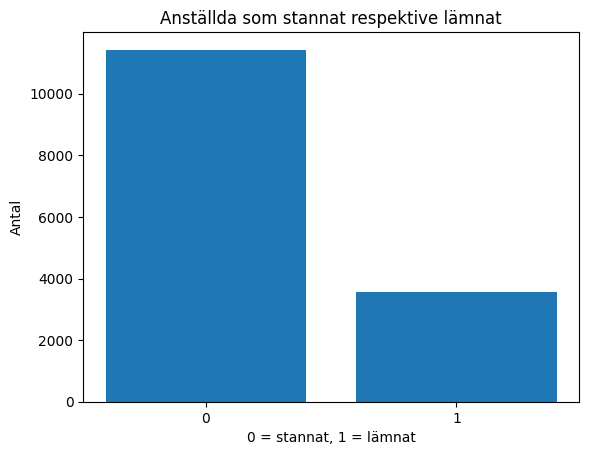

In [5]:
left_counts = df_hr["left"].value_counts().sort_index()

plt.bar(left_counts.index.astype(str), left_counts.values)
plt.title("Anställda som stannat respektive lämnat")
plt.xlabel("0 = stannat, 1 = lämnat")
plt.ylabel("Antal")
plt.show()

### Nöjdhet och arbetstid

Här jämförs de som stannat med de som lämnat. Det är framför allt intressant att se om grupperna skiljer sig i nöjdhet och arbetsbelastning.

In [6]:
summary_left = df_hr.groupby("left")[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company"
    ]
].mean().round(2)

summary_left

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
left,,,,,
0,0.67,0.72,3.79,199.06,3.38
1,0.44,0.72,3.86,207.42,3.88


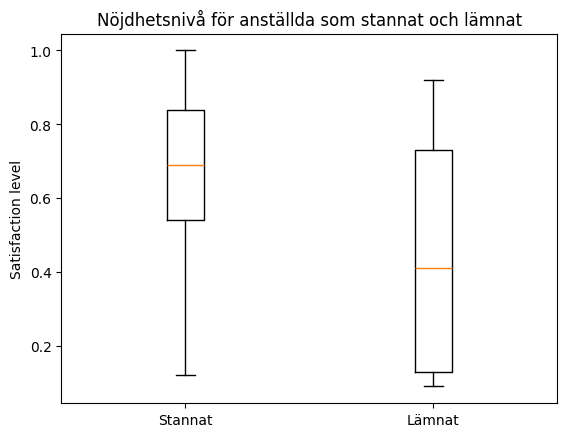

In [7]:
stayed = df_hr.loc[df_hr["left"] == 0, "satisfaction_level"]
left = df_hr.loc[df_hr["left"] == 1, "satisfaction_level"]

plt.boxplot([stayed, left], tick_labels=["Stannat", "Lämnat"])
plt.title("Nöjdhetsnivå för anställda som stannat och lämnat")
plt.ylabel("Satisfaction level")
plt.show()

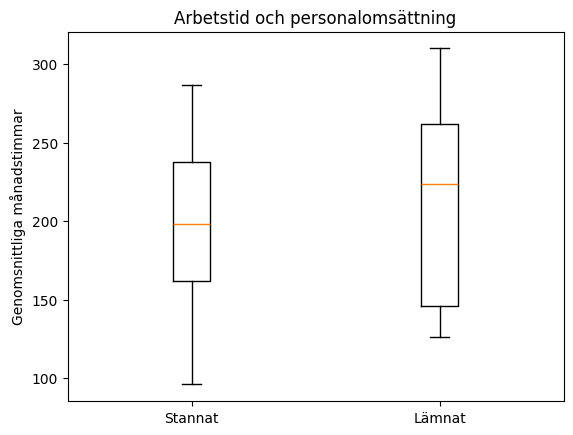

In [8]:
stayed_hours = df_hr.loc[df_hr["left"] == 0, "average_montly_hours"]
left_hours = df_hr.loc[df_hr["left"] == 1, "average_montly_hours"]

plt.boxplot([stayed_hours, left_hours], tick_labels=["Stannat", "Lämnat"])
plt.title("Arbetstid och personalomsättning")
plt.ylabel("Genomsnittliga månadstimmar")
plt.show()

### Lön, avdelning och befordran

Här tittar jag på vilka grupper som har högst andel personer som lämnat.

In [9]:
turnover_salary = (
    df_hr.groupby("salary")["left"]
    .agg(["count", "mean"])
    .rename(columns={"count": "antal", "mean": "andel_som_lämnat"})
)

turnover_salary["andel_som_lämnat"] = (turnover_salary["andel_som_lämnat"] * 100).round(1)
turnover_salary.sort_values("andel_som_lämnat", ascending=False)

,antal,andel_som_lämnat
salary,,
low,7316,29.7
medium,6446,20.4
high,1237,6.6


In [10]:
turnover_department = (
    df_hr.groupby("Department")["left"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(1)
)

turnover_department

Department
hr             29.1
accounting     26.6
technical      25.6
support        24.9
sales          24.5
marketing      23.7
IT             22.2
product_mng    22.0
RandD          15.4
management     14.4
Name: left, dtype: float64

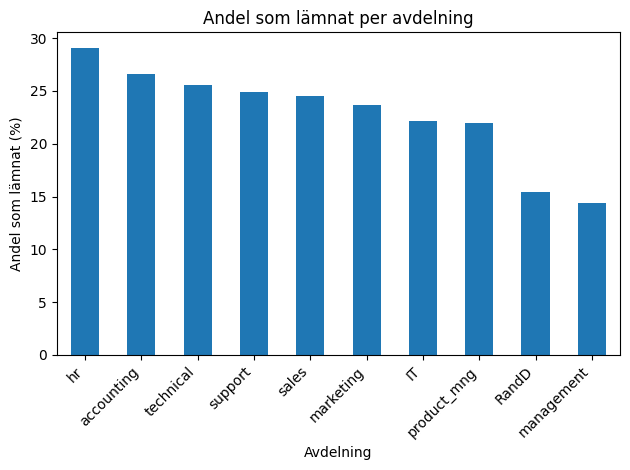

In [11]:
turnover_department.plot(kind="bar")
plt.title("Andel som lämnat per avdelning")
plt.ylabel("Andel som lämnat (%)")
plt.xlabel("Avdelning")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
promotion_summary = (
    df_hr.groupby("promotion_last_5years")["left"]
    .agg(["count", "mean"])
    .rename(columns={"count": "antal", "mean": "andel_som_lämnat"})
)

promotion_summary["andel_som_lämnat"] = (promotion_summary["andel_som_lämnat"] * 100).round(1)
promotion_summary

,antal,andel_som_lämnat
promotion_last_5years,,
0,14680,24.2
1,319,6.0


### Analys till ledningsgruppen

Resultaten pekar framför allt på att personalomsättningen hänger ihop med hur nöjda de anställda är och hur deras arbetssituation ser ut.

De som lämnat har i genomsnitt lägre `satisfaction_level`. Det finns också skillnader i arbetstid, antal projekt och hur länge personerna varit på företaget.

Lönenivå och avdelning skiljer sig också i andelen som lämnar. Det betyder inte automatiskt att exempelvis låg lön orsakar att någon slutar, men det är tydliga grupper som ledningen kan undersöka vidare.

Jag hade därför främst följt upp arbetsbelastning, nöjdhet, lön och utvecklingsmöjligheter. Datan visar samband, men EDA:n räcker inte för att säga att en viss faktor ensam är orsaken.

## Fråga 16

**Frågeställning:**

### Gör ett komplett ML-flöde där diamantpriser i `diamonds.csv` modelleras.

Målet är att prediktera `price`.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [14]:
diamonds_path = Path("chapter_03_regression/data/diamonds.csv")
if not diamonds_path.exists():
    diamonds_path = Path("data/diamonds.csv")

diamonds = pd.read_csv(diamonds_path)
diamonds = diamonds.drop(columns=["Unnamed: 0"], errors="ignore")

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [15]:
print("Antal rader:", len(diamonds))
print("Saknade värden:", int(diamonds.isna().sum().sum()))
print()
diamonds.info()

Antal rader: 53940
Saknade värden: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [16]:
diamonds.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


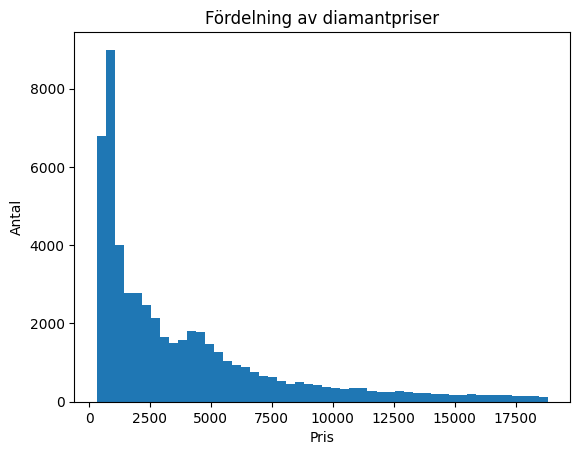

In [17]:
plt.hist(diamonds["price"], bins=50)
plt.title("Fördelning av diamantpriser")
plt.xlabel("Pris")
plt.ylabel("Antal")
plt.show()

Priset är tydligt högerskevt. Datasetet innehåller både numeriska och kategoriska features, så de kategoriska variablerna behöver kodas innan de kan användas av modellerna.

In [18]:
X = diamonds.drop(columns="price")
y = diamonds["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Kategoriska features:", categorical_features)
print("Numeriska features:", numerical_features)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Kategoriska features: ['cut', 'color', 'clarity']
Numeriska features: ['carat', 'depth', 'table', 'x', 'y', 'z']
Train: (43152, 9)
Test: (10788, 9)


In [19]:
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        ("model", LinearRegression()),
    ]
)

forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

### Modellval

Jag jämför först linjär regression och Random Forest med cross-validation på träningsdatan. Testdatan lämnas orörd tills modellen är vald.

In [20]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": forest_model,
}

cv_results = {}

for name, model in models.items():
    scores = -cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
    )
    cv_results[name] = scores.mean()

pd.Series(cv_results, name="CV RMSE").sort_values()

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 134, in call
BrokenPipeError: [Errno 32] Broken pipe

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 718, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 544, in _warm_drawing_and_image_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 590, in _warm_chart_t

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 32317, in hydrate_crdt_from_proto
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.

Random Forest         564.746510
Linear Regression    1129.713105
Name: CV RMSE, dtype: float64

In [21]:
best_name = min(cv_results, key=cv_results.get)
best_model = models[best_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Vald modell:", best_name)
print("Test RMSE:", round(rmse, 2))
print("Test MAE:", round(mae, 2))
print("Test R²:", round(r2, 4))

Vald modell: Random Forest
Test RMSE: 550.09
Test MAE: 270.19
Test R²: 0.981


In [22]:
comparison = pd.DataFrame({
    "Faktiskt pris": y_test.iloc[:10].values,
    "Predikterat pris": np.round(y_pred[:10], 0)
})

comparison

,Faktiskt pris,Predikterat pris
0,559,568.0
1,2201,2316.0
2,1238,1208.0
3,1304,1256.0
4,6901,10070.0
5,3011,4169.0
6,1765,1797.0
7,1679,1795.0
8,2102,2061.0
9,4789,5869.0


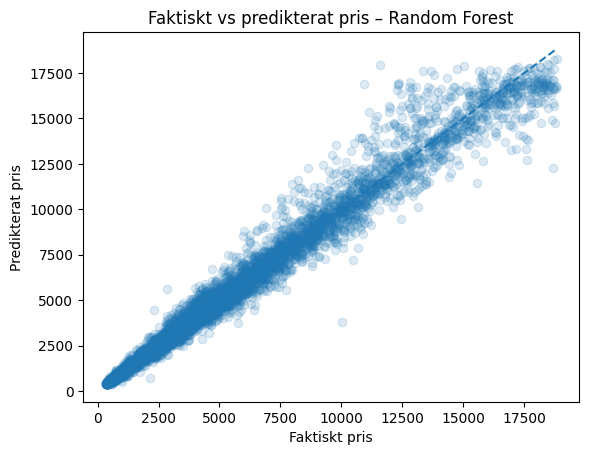

In [23]:
plt.scatter(y_test, y_pred, alpha=0.15)
plt.xlabel("Faktiskt pris")
plt.ylabel("Predikterat pris")
plt.title(f"Faktiskt vs predikterat pris – {best_name}")

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.show()

### Slutsats

Jag började med ett enkelt flöde och jämförde två regressionsmodeller med cross-validation. Modellen med lägst CV-RMSE valdes och utvärderades sedan en gång på testdatan.

RMSE och MAE visar hur stora prediktionsfelen är i samma enhet som priset, medan R² visar hur stor del av variationen i diamantpriserna modellen förklarar.

Det här är ett fungerande grundflöde. Det hade kunnat förbättras vidare med exempelvis hyperparameter tuning och mer feature engineering.